In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

if os.getenv("GROQ_API_KEY") is None:
    raise ValueError("GROQ_API_KEY is not set")
else:
    print("GROQ_API_KEY is set")

GROQ_API_KEY is set


In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7fa8434b0ec0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7fa8434b1be0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

## Here we will use the inbuilt messages and add_messages  from langgraph

### Step 1: create a graph schema

In [3]:
from typing import TypedDict, List, Annotated  # Annotated is used to add metadata to type hints. For example, Annotated[int, "must be positive"] means int type with extra info.
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List, add_messages]





### Step 2: create a node function

In [4]:
def welcome(schema: graph_schema) -> graph_schema:

    curr_message = schema["messages"]

    response = llm.invoke(curr_message).content

    schema_message = f"Your message was {curr_message} and my response was {response}"

    return schema
    

## Step 3: Create the state graph

In [8]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("welcome", welcome)

graph.add_edge(START, "welcome")

graph.add_edge("welcome", END)



### Step 4: compile the graph with checkpoint

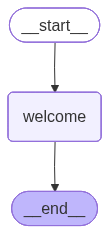

In [9]:
from langgraph.checkpoint.memory import InMemorySaver

checkpoint = InMemorySaver()
memory_graph = graph.compile(checkpointer=checkpoint)


from IPython.display import Image, display
Image(memory_graph.get_graph().draw_mermaid_png())


## Step 5: Run the graph with config

In [11]:
response = memory_graph.invoke({"messages": "Hello, My name is Atul"},
                                {"configurable": {"thread_id": "1"}})

for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hello, My name is Atul


In [13]:
response = memory_graph.invoke({"messages": "Hello, what is my name"},
                                {"configurable": {"thread_id": "1"}})

print(response)
for message in response["messages"]:
    message.pretty_print()

{'messages': [HumanMessage(content='Hello, My name is Atul', additional_kwargs={}, response_metadata={}, id='617f1e1b-bcb4-4ace-a795-4b6f12979d06'), HumanMessage(content='Hello, what is my name', additional_kwargs={}, response_metadata={}, id='75c58f3b-04f0-47bb-9767-31e9792995b7'), HumanMessage(content='Hello, what is my name', additional_kwargs={}, response_metadata={}, id='ea29d5ab-d518-4c33-a98c-34075c077667')]}
================================ Human Message =================================

Hello, My name is Atul
================================ Human Message =================================

Hello, what is my name
================================ Human Message =================================

Hello, what is my name
